<a href="https://colab.research.google.com/github/Juan-Medinaa/talento_tech/blob/main/conexion/RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
X = [1, 2, 2, 3, 4, 4, 5, 6]
Y = [2, 3, 4, 4, 4, 6, 5, 7]
datos = {'X':X,
        'Y':Y}

df = pd.DataFrame(datos)
df

,X,Y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,6
6,5,5
7,6,7


In [ ]:
df['XY'] = df['X'] * df['Y']
df

,X,Y,XY
0,1,2,2
1,2,3,6
2,2,4,8
3,3,4,12
4,4,4,16
5,4,6,24
6,5,5,25
7,6,7,42


In [ ]:
df['X2'] = df['X'] ** 2
df

,X,Y,XY,X2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36


In [ ]:
df.loc['Total'] = df.sum()
df

,X,Y,XY,X2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36
Total,27,35,135,111


In [ ]:
sum_x = df.loc['Total', 'X']
sum_y = df.loc['Total', 'Y']
sum_xy = df.loc['Total', 'XY']
sum_x2 = df.loc['Total', 'X2']

n = len(X) # X is the original list before adding the 'Total' row

print(f"sum_x: {sum_x}")
print(f"sum_y: {sum_y}")
print(f"sum_xy: {sum_xy}")
print(f"sum_x2: {sum_x2}")
print(f"n: {n}")

sum_x: 27
sum_y: 35
sum_xy: 135
sum_x2: 111
n: 8


In [ ]:
num=(n*sum_xy-sum_x*sum_y)
den=(n*sum_x2-sum_x**2)
m=num/den
print(f"m: {m}")

m: 0.8490566037735849


In [ ]:
mean_y=sum_y/n
mean_x=sum_x/n
b=mean_y-m*mean_x
print(b)

1.5094339622641506


In [ ]:
print(f"y = {m}x + {b}")
#

y = 0.8490566037735849x + 1.5094339622641506


In [ ]:
#decirle a gemini que haga una grafica de regresion lineal, graficar puntos X,Y

In [ ]:
#hazme un scatterplot de la tabla X, Y, graficame la recta de regresion lineal, porque al pendiente es m y el intercepto es b
#cuantificar el error

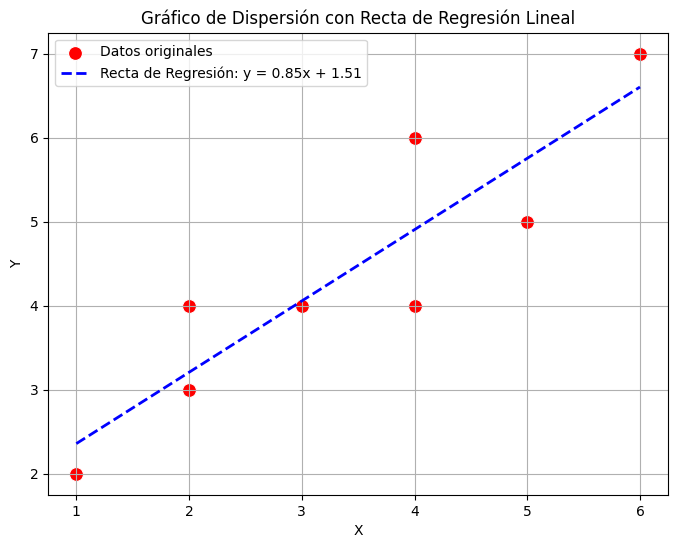

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X, y=Y, s=100, color='red', label='Datos originales')

# Plot the regression line
x_reg = np.array([min(X), max(X)])
y_reg = m * x_reg + b
plt.plot(x_reg, y_reg, color='blue', linestyle='--', linewidth=2, label=f'Recta de Regresión: y = {m:.2f}x + {b:.2f}')

plt.title('Gráfico de Dispersión con Recta de Regresión Lineal')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df = df.drop(df.index[-1])
df

,X,Y,XY,X2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36


In [ ]:
df['Y_pred']=m*df['X']+b
df

,X,Y,XY,X2,Y_pred
0,1,2,2,1,2.358491
1,2,3,6,4,3.207547
2,2,4,8,4,3.207547
3,3,4,12,9,4.056604
4,4,4,16,16,4.905660
5,4,6,24,16,4.905660
6,5,5,25,25,5.754717
7,6,7,42,36,6.603774


In [ ]:
df['Y-Y_pred']=df['Y']-df['Y_pred']
df
#

,X,Y,XY,X2,Y_pred,Y-Y_pred
0,1,2,2,1,2.358491,-0.358491
1,2,3,6,4,3.207547,-0.207547
2,2,4,8,4,3.207547,0.792453
3,3,4,12,9,4.056604,-0.056604
4,4,4,16,16,4.905660,-0.905660
5,4,6,24,16,4.905660,1.094340
6,5,5,25,25,5.754717,-0.754717
7,6,7,42,36,6.603774,0.396226


In [ ]:
df['Error_squared']=df['Y-Y_pred']**2
df

,X,Y,XY,X2,Y_pred,Y-Y_pred,Error_squared
0,1,2,2,1,2.358491,-0.358491,0.128515
1,2,3,6,4,3.207547,-0.207547,0.043076
2,2,4,8,4,3.207547,0.792453,0.627981
3,3,4,12,9,4.056604,-0.056604,0.003204
4,4,4,16,16,4.905660,-0.905660,0.820221
5,4,6,24,16,4.905660,1.094340,1.197579
6,5,5,25,25,5.754717,-0.754717,0.569598
7,6,7,42,36,6.603774,0.396226,0.156995


In [ ]:
#df.loc['Total'] = df.sum()
#df

In [ ]:
Sr=df['Error_squared'].sum()
print(Sr, Sr/n, (Sr/n)**0.5)


#

3.5471698113207544 0.4433962264150943 0.6658800390574073


In [ ]:
df['Error_abs']=abs(df['Y-Y_pred'])
df

,X,Y,XY,X2,Y_pred,Y-Y_pred,Error_squared,Error_abs
0,1,2,2,1,2.358491,-0.358491,0.128515,0.358491
1,2,3,6,4,3.207547,-0.207547,0.043076,0.207547
2,2,4,8,4,3.207547,0.792453,0.627981,0.792453
3,3,4,12,9,4.056604,-0.056604,0.003204,0.056604
4,4,4,16,16,4.905660,-0.905660,0.820221,0.905660
5,4,6,24,16,4.905660,1.094340,1.197579,1.094340
6,5,5,25,25,5.754717,-0.754717,0.569598,0.754717
7,6,7,42,36,6.603774,0.396226,0.156995,0.396226


In [ ]:
Error_abs=df['Error_abs'].sum()
print(Error_abs, Error_abs/n)
#

4.566037735849056 0.570754716981132


### Cuantificación del Error del Modelo de Regresión Lineal

Vamos a calcular las métricas de error para evaluar la precisión de nuestro modelo de regresión lineal. Las métricas que calcularemos son:

*   **Error Cuadrático Medio (MSE - Mean Squared Error):** Mide el promedio de los cuadrados de los errores, es decir, la diferencia cuadrada promedio entre los valores estimados y los valores reales.
*   **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error):** Es la raíz cuadrada del MSE y proporciona una medida del error en las mismas unidades que la variable de respuesta.
*   **Error Absoluto Medio (MAE - Mean Absolute Error):** Mide el promedio de las diferencias absolutas entre las predicciones y los valores reales. Es menos sensible a los valores atípicos que el MSE.
*   **Coeficiente de Determinación (R-cuadrado):** Indica la proporción de la varianza en la variable dependiente que es predecible a partir de la variable(s) independiente(s). Un valor más cercano a 1 indica un mejor ajuste.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Original X and Y values (from the first cell)
X_original = np.array(X)
Y_original = np.array(Y)

# Predict Y values using the regression line equation: y = mx + b
Y_predicted = m * X_original + b

# Calculate error metrics
mse = mean_squared_error(Y_original, Y_predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_original, Y_predicted)
r_squared = r2_score(Y_original, Y_predicted)

print(f"Predicted Y values: {Y_predicted}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared: {r_squared}")

Predicted Y values: [2.35849057 3.20754717 3.20754717 4.05660377 4.90566038 4.90566038
 5.75471698 6.60377358]
Mean Squared Error (MSE): 0.4433962264150943
Root Mean Squared Error (RMSE): 0.6658800390574073
Mean Absolute Error (MAE): 0.570754716981132
R-squared: 0.8015569336324053


In [ ]:
print(f'mean squared error: {Sr/n}')
print(f'root mean squared error: {(Sr/n)**0.5}')
print(f'mean absolute error: {Error_abs/n}')
#

mean squared error: 0.4433962264150943
root mean squared error: 0.6658800390574073
mean absolute error: 0.570754716981132


In [ ]:
mape = np.mean(np.abs((Y_original - Y_predicted) / Y_original)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 13.46%
